In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski
import bm3d
import os
import importlib
import modules.optics as op
from modules.noise import gauss_noise, poisson_noise, salt_pepper_noise, mix_noise

(1024, 1024)


<Figure size 640x480 with 0 Axes>

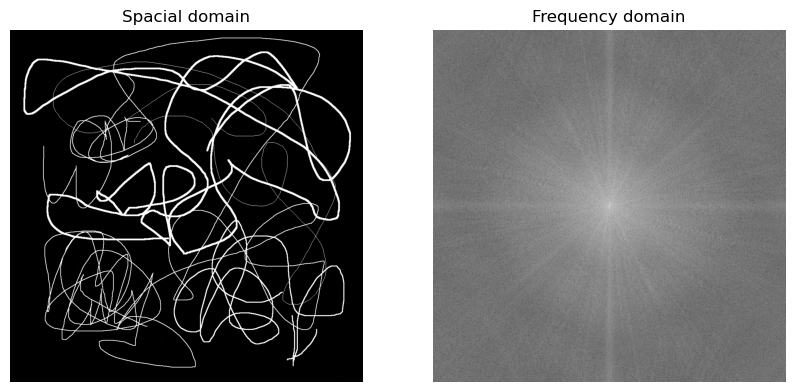

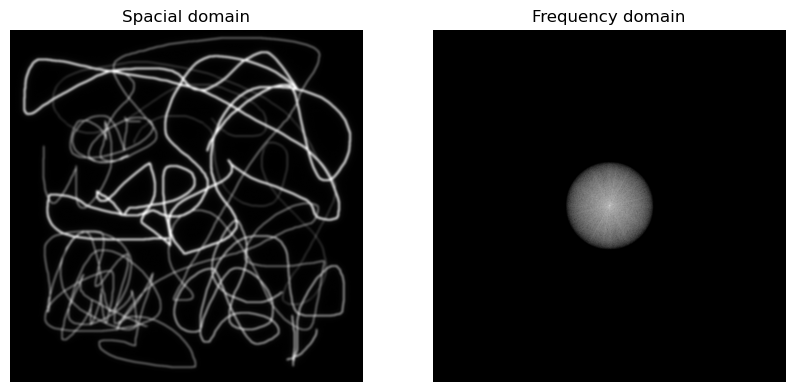

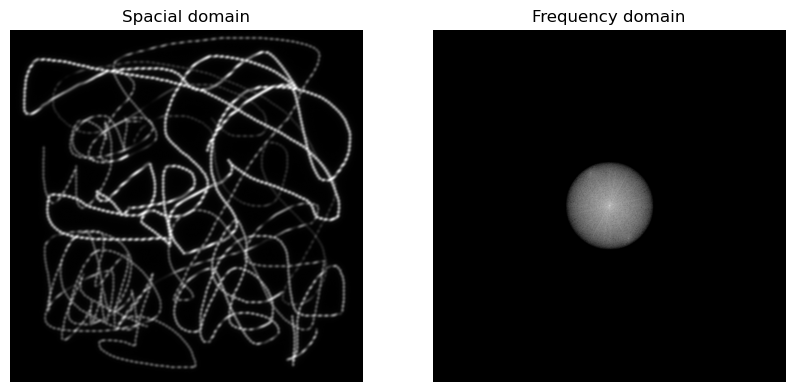

In [17]:
plt.set_cmap('gray')

center_dot_gt = ski.io.imread('source_images\center_dot.tif')
dotted_gt = ski.io.imread('source_images\dotted_line.tif')
synthetic_gt = ski.img_as_float(ski.color.rgb2gray(ski.io.imread('source_images\Synthetic512.png')))
line_gt = ski.io.imread('lines/lines_gt.tif')
test_gt = ski.io.imread('lines/Test.tif')


image = test_gt
widefield = op.otf_incoherent(image, NA=1.2, wavelength=480, pixelsize=25)
grated = image * op.grating(len(image), angle=60,  phase=0, NA=1.2, wavelength=280, pixelsize=25)
sim = op.otf_incoherent(grated, NA=1.2, wavelength=480, pixelsize=25)
print(image.shape)
op.display_fourier(image)
op.display_fourier(widefield)
op.display_fourier(sim)

In [ ]:
illuminated = np.zeros((9, image.shape[0], image.shape[1]))
angleset = [[15, 135, 255], [15, 134, 256], [15, 133, 257], [15, 132, 258], [15, 140, 251]]
phases = [0, 120, 240]

n = 9
     
illuminated = np.zeros((n, image.shape[0], image.shape[1]))
raw_noisefree = np.zeros((n, image.shape[0]//2, image.shape[1]//2))

angles = angleset[4]
for i in range(3):
    for j in range(3):
        illuminated[3*i + j] = image * op.grating(len(image), angle=angles[i],  phase=phases[j], NA=1.2, wavelength=680, pixelsize=100)

raw_noisefree = op.otf_incoherent(illuminated) # Ground truth

print(raw_noisefree.shape)
# Add noise to the images
percentage = 0.05
folder_path = 'output_images/illumination_angles/5percent/'
# gaussian_noisy = gauss_noise(illuminated, percentage)
# poisson_noisy = poisson_noise(illuminated, percentage)
# saltpepper_noisy = salt_pepper_noise(illuminated, percentage)
mix_noisy = mix_noise(illuminated, percentage)

# Apply low-pass filter
# raw_gaussian = op.otf_incoherent(gaussian_noisy, NA=1.2, wavelength=600, pixelsize=100)
# raw_poisson = op.otf_incoherent(poisson_noisy, NA=1.2, wavelength=600, pixelsize=100)
# raw_saltpepper = op.otf_incoherent(saltpepper_noisy, NA=1.2, wavelength=600, pixelsize=100)
raw_mix = op.otf_incoherent(mix_noisy, NA=1.2, wavelength=600, pixelsize=100)

noisy_image = raw_mix

noisy_PSNR = np.zeros(n)
noisy_SSIM = np.zeros(n)

for i in range(n):
    noisy_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], noisy_image[i])
    noisy_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], noisy_image[i], data_range=1)

print("Noisy PSNR: ", np.mean(noisy_PSNR))
print("Noisy SSIM: ", np.mean(noisy_SSIM))

# fig, ax = plt.subplots(3, 3, figsize=(10, 10))
# for i in range(9):
#     r = i//3
#     c = i%3
#     ax[r, c].imshow(raw_mix[i], vmin=0, vmax=1)
#     ax[r, c].axis('off')
# plt.show()
# plt.imshow(np.sum(noisy_image, axis=0))
# plt.show()

(9, 256, 256)
Noisy PSNR:  30.094226984395934
Noisy SSIM:  0.8709288520229078


In [12]:
# Richardson-Lucy filter
rl_raw = np.zeros((n, 256, 256))
psf = op.gaussian_psf(3)

for i in range(n):
    rl_raw[i] = ski.restoration.richardson_lucy(noisy_image[i], psf, num_iter=30)

rl_PSNR = np.zeros(n)
rl_SSIM = np.zeros(n)

for i in range(n):
    rl_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], rl_raw[i])
    rl_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], rl_raw[i], data_range=1)

print("RL PSNR: ", np.mean(rl_PSNR))
print("RL SSIM: ", np.mean(rl_SSIM))

# Save images
# ski.io.imsave(os.path.join(folder_path, 'rl_raw.tif'), rl_raw)

RL PSNR:  31.284760970523653
RL SSIM:  0.8892740513796838


In [13]:
data = {
    'Filter': ['Noisy', 'RL'],
    'PSNR': [np.mean(noisy_PSNR), np.mean(rl_PSNR)],
    'SSIM': [np.mean(noisy_SSIM), np.mean(rl_SSIM)],
}

# Create a DataFrame
df = pd.DataFrame(data)
display(df)

# Save all data
save = 1
if save:
    all_filters_raw = np.stack([noisy_image, rl_raw])
    ski.io.imsave(os.path.join(folder_path, 'angle4.tif'), all_filters_raw)
    df.to_csv(os.path.join(folder_path, 'raw_angle4.csv'), index=False)

# ski.io.imsave(os.path.join(folder_path, 'raw_noisefree_angle1.tif'), raw_noisefree)


,Filter,PSNR,SSIM
0,Noisy,30.094227,0.870929
1,RL,31.284761,0.889274
